# Markowitz Single-Window Efficient Frontier (60-month window)

The optimization procedure follows the parametric active-set approach described by **Stein, Branke, and Schmeck (2008), _Efficient implementation of an active set algorithm for large-scale portfolio selection_**. Rather than solving many independent portfolio-optimization problems, we begin at the maximum-return portfolio and move along the efficient frontier from one **corner portfolio** to the next.

**Constraints.** Portfolio weights must be non-negative (no short sales) and sum to one (fully invested). Short positions are economically unbounded for a large fund -- a rational limit would require either an arbitrary position cap or a no-short constraint -- and a no-short constraint also matches how the largest long-only institutional mandates are actually run.

## Economic question

Index concentration is a live debate in practice: a handful of mega-cap stocks drive most of a market-cap-weighted index's risk and return, and critics argue this leaves investors under-diversified relative to what they think they own. This notebook asks a sharper, testable version of that question using the 15 largest U.S. stocks just before the 2008 financial crisis: **does a mean-variance-optimal (minimum-variance) investor want to hold these stocks in roughly the same proportions as the market does, or does the optimizer actively steer away from the biggest, most-correlated names? And if the two portfolios differ, did that difference matter once the crisis actually hit?**

## Methodology at a glance

- **Selection criterion: global minimum variance**, compared explicitly against market-cap weighting (Section 10) -- not evaluated in isolation.
- **Universe: the 15 largest U.S. common stocks by market capitalization**, as of the end of the estimation window, among stocks with a complete 60-month return history. A small, concrete universe like this keeps the sample covariance matrix well-conditioned (15 assets vs. 60 monthly observations) without needing any shrinkage or regularization, and keeps every table in this report -- means, standard deviations, the full correlation matrix, portfolio weights -- reportable in full, not as an excerpt.
- **Estimation window: 2003-01 through 2007-12 (60 months)**, ending immediately before the 2008 financial crisis -- chosen deliberately so the comparison in Section 11 (did the difference matter) has a real stress period to test against.

## 1. Setup and load the cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
CLEAN_DIR = PROJECT_ROOT / "data" / "clean"

In [2]:
df_stocks = pd.read_parquet(CLEAN_DIR / "monthly_stock_clean.parquet")
df_stocks["trade_date"] = pd.to_datetime(df_stocks["trade_date"])

print(f"df_stocks rows: {len(df_stocks):,}")
print(f"Date range: {df_stocks['trade_date'].min().date()} to {df_stocks['trade_date'].max().date()}")

df_stocks rows: 389,279
Date range: 2003-01-31 to 2009-12-31


## 2. Build the 60-month stock-return window

The raw stock data is stored in long format, with one row per stock-month observation. For portfolio optimization, it is more convenient to work with a return matrix:

- **rows:** months;
- **columns:** stocks;
- **values:** monthly stock returns.

We use the estimation window **2003-01 through 2007-12**, ending immediately before the 2008 financial crisis. The cleaned data extends through 2009-12 specifically so Section 11 can test both portfolios against realized returns through the crisis.

In [3]:
# Create single stock return matrix (n x m; n as periods, m as assets)
df_stocks["month"] = df_stocks["trade_date"].dt.to_period("M")

stock_returns = df_stocks.pivot(
    index="month",
    columns="cusip_crsp_id",
    values="monthly_return"
)

stock_returns = stock_returns.sort_index()

stock_returns.shape

(84, 6832)

In [4]:
WINDOW_START = "2003-01"
WINDOW_END = "2007-12"

window = stock_returns.loc[WINDOW_START:WINDOW_END].copy()

print("Window shape:", window.shape)
print("Start:", window.index[0])
print("End:", window.index[-1])
assert window.shape[0] == 60, "expected exactly 60 months in the estimation window"

Window shape: (60, 6832)
Start: 2003-01
End: 2007-12


## 3. Select the universe: 15 largest stocks with complete history

Two filters, applied in order:

1. **Complete history.** A stock must have all 60 monthly observations in the window (needed for the covariance matrix to be well-defined from this sample).
2. **Market capitalization.** Among those, keep the 15 largest by market cap (`|price| x shares outstanding`) as of the window's final month. Market cap is read from `monthly_market_cap.parquet` (built in `../02_clean/data_clean.ipynb`); this same table is reused in Section 10 to build the market-cap-weighted comparison portfolio.

In [5]:
TOP_N_UNIVERSE = 15

# --- complete-history filter ---
min_obs = int(np.ceil(len(window)))
obs_count = window.notna().sum()
eligible_assets = obs_count[obs_count >= min_obs].index

print("Assets before filtering:", window.shape[1])
print("Assets with complete history:", len(eligible_assets))

# --- market-cap filter ---
market_cap = pd.read_parquet(CLEAN_DIR / "monthly_market_cap.parquet")
market_cap["month_end_date"] = pd.to_datetime(market_cap["month_end_date"])

window_end_cap = (
    market_cap
    .loc[market_cap["month_end_date"].dt.to_period("M") == pd.Period(WINDOW_END, freq="M")]
    .set_index("cusip_crsp_id")["market_cap"]
    .reindex(eligible_assets)
)

top_assets = window_end_cap.dropna().sort_values(ascending=False).head(TOP_N_UNIVERSE).index

window_filtered = window[top_assets].copy()

print(f"Final universe: {window_filtered.shape[1]} stocks (top {TOP_N_UNIVERSE} by market cap)")
print("Window shape:", window_filtered.shape)

Assets before filtering: 6832
Assets with complete history: 3277


Final universe: 15 stocks (top 15 by market cap)
Window shape: (60, 15)


## 4. Estimate expected returns and the covariance matrix

With 15 assets and 60 monthly observations, the sample covariance matrix is comfortably well-conditioned (far more observations than assets) -- no shrinkage or regularization is needed. We simply check that the resulting matrix is symmetric and positive (semi)definite before using it, as the active-set algorithm requires.

In [6]:
mu = window_filtered.mean()
Sigma = window_filtered.cov()

mu_vec = mu.to_numpy().reshape(-1, 1)
Sigma_mat = Sigma.to_numpy()

print("mu shape:", mu_vec.shape)
print("Sigma shape:", Sigma_mat.shape)
print("NaNs in Sigma:", np.isnan(Sigma_mat).sum())
print("Symmetric:", np.allclose(Sigma_mat, Sigma_mat.T))

eigenvalues = np.linalg.eigvalsh(Sigma_mat)
min_eigenvalue = eigenvalues[0]
print("Minimum eigenvalue:", min_eigenvalue)

if min_eigenvalue > 0:
    print("Sigma is positive definite, perfect!")
elif np.isclose(min_eigenvalue, 0):
    print("Sigma is positive semidefinite, yay!")
else:
    print("Sigma is indefinite.")

mu shape: (15, 1)
Sigma shape: (15, 15)
NaNs in Sigma: 0
Symmetric: True
Minimum eigenvalue: 0.00034595035237141073
Sigma is positive definite, perfect!


## 5. Start at the maximum-return portfolio

The parametric algorithm begins at a known point on the efficient frontier: the portfolio placing 100% of its weight in the single stock with the highest estimated expected return (the only feasible "maximum return" point under a long-only, fully-invested constraint).

See **Stein, Branke, and Schmeck (2008), Section 2**, for the initialization of the parametric algorithm.

In [7]:
n_assets = len(mu_vec)
tol = 1e-12

max_return_idx = np.argmax(mu_vec[:, 0])

x = np.zeros((n_assets, 1))
x[max_return_idx, 0] = 1.0

free_assets = np.array([max_return_idx], dtype=int)
fixed_assets = np.setdiff1d(np.arange(n_assets), free_assets)

e_current = np.inf

print("Initial free asset:", free_assets, "->", window_filtered.columns[max_return_idx])
print("Maximum expected return:", mu_vec[max_return_idx, 0])

Initial free asset: [9] -> 03783310_14593
Maximum expected return: 0.06201432650934741


## 6. Solve the reduced kernel system

Stein, Branke, and Schmeck substitute out variables sitting at a bound rather than repeatedly solving one large system. The function below builds the reduced **kernel system** for the currently free assets and the fully-invested constraint, solving it once for the constant part of the solution and once for the part that changes with the frontier parameter.

See **Sections 4.2-4.3, equations (13)-(14)** of Stein, Branke, and Schmeck (2008).

In [8]:
def solve_kernel(free_assets):
    C_K = Sigma_mat[np.ix_(free_assets, free_assets)]
    mu_K = mu_vec[free_assets]

    A_g = np.ones((1, len(free_assets)))

    H_K = np.block([
        [C_K, A_g.T],
        [A_g, np.zeros((1, 1))]
    ])

    rhs_q = np.vstack([
        np.zeros((len(free_assets), 1)),
        [[1.0]]
    ])

    rhs_p = np.vstack([
        mu_K,
        [[0.0]]
    ])

    h_q = np.linalg.solve(H_K, rhs_q)
    h_p = np.linalg.solve(H_K, rhs_p)

    return h_q, h_p

## 7. Identify the next corner portfolio

Within a frontier segment, the active set stays unchanged. The segment ends when a free stock reaches zero weight (leaves) or a bounded stock becomes eligible to enter. `next_corner()` finds whichever event happens first as the frontier parameter decreases.

See **Stein, Branke, and Schmeck (2008), Section 2**.

In [9]:
def next_corner(free_assets, e_current):
    fixed_assets = np.setdiff1d(
        np.arange(n_assets),
        free_assets
    )

    h_q, h_p = solve_kernel(free_assets)

    n_free = len(free_assets)

    x_q = h_q[:n_free, 0]
    x_p = h_p[:n_free, 0]

    g_q = h_q[n_free, 0]
    g_p = h_p[n_free, 0]

    # -----------------------------------
    # 1. Free asset hits lower bound
    # -----------------------------------
    leave_e = -np.inf
    leave_asset = None

    for i, asset in enumerate(free_assets):
        if abs(x_p[i]) > tol:
            e = -x_q[i] / x_p[i]

            if (
                e >= 0
                and e < e_current - tol
                and e > leave_e
            ):
                leave_e = e
                leave_asset = asset

    # -----------------------------------
    # 2. Bounded asset becomes free
    # -----------------------------------
    enter_e = -np.inf
    enter_asset = None

    if len(fixed_assets) > 0:
        C_BF = Sigma_mat[np.ix_(fixed_assets, free_assets)]
        mu_B = mu_vec[fixed_assets, 0]

        beta_q = C_BF @ x_q + g_q
        beta_p = C_BF @ x_p + g_p - mu_B

        roots = np.full(len(fixed_assets), np.nan)

        valid = np.abs(beta_p) > tol
        roots[valid] = -beta_q[valid] / beta_p[valid]

        valid &= (
            (roots >= 0)
            & (roots < e_current - tol)
        )

        if np.any(valid):
            j = np.argmax(
                np.where(valid, roots, -np.inf)
            )

            enter_e = roots[j]
            enter_asset = fixed_assets[j]

    # -----------------------------------
    # Decide which event happens first
    # -----------------------------------
    if enter_e >= leave_e:
        return enter_e, "enter", enter_asset

    return leave_e, "leave", leave_asset

## 8. Trace the complete efficient frontier

Repeatedly find the next active-set change, update the free set, and solve for the new corner portfolio. The loop stops when the frontier parameter reaches zero -- the **global minimum-variance endpoint**.

In [10]:
corner_weights = []
corner_e = []
corner_free_sets = []

corner_weights.append(x.copy())
corner_e.append(np.inf)
corner_free_sets.append(free_assets.copy())

while True:

    e_next, event, asset = next_corner(
        free_assets,
        e_current
    )

    if not np.isfinite(e_next) or e_next <= tol:
        e_next = 0.0

        h_q, h_p = solve_kernel(free_assets)
        solution = h_q + e_next * h_p

        x = np.zeros((n_assets, 1))
        x[free_assets, 0] = solution[:len(free_assets), 0]
        x[np.abs(x) < tol] = 0.0

        corner_weights.append(x.copy())
        corner_e.append(e_next)
        corner_free_sets.append(free_assets.copy())

        break

    if event == "enter":
        free_assets = np.sort(
            np.append(free_assets, asset)
        )
    elif event == "leave":
        free_assets = free_assets[
            free_assets != asset
        ]

    e_current = e_next

    h_q, h_p = solve_kernel(free_assets)
    solution = h_q + e_current * h_p

    x = np.zeros((n_assets, 1))
    x[free_assets, 0] = solution[:len(free_assets), 0]
    x[np.abs(x) < tol] = 0.0

    corner_weights.append(x.copy())
    corner_e.append(e_current)
    corner_free_sets.append(free_assets.copy())

    print(
        f"Corner {len(corner_e)-1}: "
        f"e={e_current:.6f}, "
        f"free assets={len(free_assets)}, "
        f"event={event}, "
        f"asset={asset}"
    )

print(f"\nTotal corner portfolios: {len(corner_weights)}")

Corner 1: e=0.225398, free assets=2, event=enter, asset=10
Corner 2: e=0.219804, free assets=3, event=enter, asset=14
Corner 3: e=0.191966, free assets=4, event=enter, asset=5
Corner 4: e=0.186997, free assets=5, event=enter, asset=4
Corner 5: e=0.126533, free assets=6, event=enter, asset=1
Corner 6: e=0.061467, free assets=7, event=enter, asset=11
Corner 7: e=0.060120, free assets=8, event=enter, asset=6
Corner 8: e=0.043603, free assets=9, event=enter, asset=7
Corner 9: e=0.034071, free assets=10, event=enter, asset=8
Corner 10: e=0.019235, free assets=11, event=enter, asset=0
Corner 11: e=0.012221, free assets=12, event=enter, asset=2
Corner 12: e=0.004124, free assets=11, event=leave, asset=14
Corner 13: e=0.004075, free assets=10, event=leave, asset=1
Corner 14: e=0.003381, free assets=9, event=leave, asset=9
Corner 15: e=0.002952, free assets=10, event=enter, asset=12

Total corner portfolios: 17


## 9. Select the minimum-variance portfolio, and report its weights

**Selection criterion: global minimum variance.** No expected-return target or risk-aversion coefficient is assumed. This avoids introducing an arbitrary parameter that would itself need separate justification, and it is the standard response to estimation-error concerns in mean-variance analysis: expected-return estimates are far noisier than variance estimates, so a criterion depending only on the (better-estimated) covariance matrix is the more robust choice.

Under this active-set algorithm, the minimum-variance portfolio is exactly the terminal corner (`corner_weights[-1]`), since the algorithm sweeps from the maximum-return portfolio down to the point where the frontier parameter reaches zero.

In [11]:
corner_returns = []
corner_vols = []

for w in corner_weights:
    ret = float((w.T @ mu_vec).item())
    var = float((w.T @ Sigma_mat @ w).item())
    corner_returns.append(ret)
    corner_vols.append(np.sqrt(max(var, 0.0)))

min_var_weights = corner_weights[-1].flatten()
min_var_return = corner_returns[-1]
min_var_vol = corner_vols[-1]

# --- constraint checks (weights sum to 1, satisfy stated constraints) ---
weights_sum = min_var_weights.sum()
min_weight = min_var_weights.min()

assert abs(weights_sum - 1.0) < 1e-6, f"weights do not sum to 1: {weights_sum}"
assert min_weight >= -1e-8, f"found a negative weight, violates long-only constraint: {min_weight}"

print(f"Weights sum to: {weights_sum:.8f}")
print(f"Minimum weight: {min_weight:.8f}  (must be >= 0, long-only constraint)")
print(f"Expected monthly return: {min_var_return:.6f}")
print(f"Monthly volatility:      {min_var_vol:.6f}")

asset_names = window_filtered.columns.to_numpy()
weights_table = (
    pd.Series(min_var_weights, index=asset_names, name="mv_weight")
    .sort_values(ascending=False)
    .to_frame()
)
weights_table["mean"] = mu.loc[weights_table.index]
weights_table["std"] = np.sqrt(np.diag(Sigma.loc[weights_table.index, weights_table.index]))

print(f"\nMinimum-variance portfolio weights, expected return, and volatility ({len(weights_table)} assets):")
weights_table

Weights sum to: 1.00000000
Minimum weight: 0.00000000  (must be >= 0, long-only constraint)
Expected monthly return: 0.008995
Monthly volatility:      0.017027

Minimum-variance portfolio weights, expected return, and volatility (15 assets):


,mv_weight,mean,std
93114210_55976,0.251402,0.001025,0.045405
06050510_59408,0.164989,0.007070,0.038086
47816010_22111,0.161928,0.005935,0.033927
16676410_14541,0.126854,0.021407,0.050926
74271810_18163,0.123824,0.011301,0.037021
02209S10_13901,0.065919,0.021708,0.073958
59491810_10107,0.042285,0.009573,0.057602
17275R10_76076,0.030120,0.014744,0.073008
71708110_21936,0.020681,-0.000971,0.053950
30231G10_11850,0.011997,0.019625,0.051288


## 10. Minimum-variance vs. market-cap weights

This is the heart of the economic question. We build the market-cap-weighted portfolio over the **same 15 stocks** (cap weight = each stock's share of the group's total market cap at the window's final month) and compare it directly to the minimum-variance weights above.

If mean-variance optimization simply reproduced market-cap weighting, there would be nothing to report -- a passive cap-weighted holding and an "optimized" one would be the same thing. The comparison below tests whether that is actually true for this universe and period.

Minimum-variance weight vs. market-cap weight, per stock:
                mv_weight  cap_weight  difference
30231G10_11850   0.011997      0.1496   -0.137603
36960430_12060   0.000000    0.109488   -0.109488
59491810_10107   0.042285     0.09706   -0.054775
00206R10_66093   0.000000    0.073662   -0.073662
74271810_18163   0.123824    0.066638    0.057186
16676410_14541   0.126854    0.057591    0.069263
47816010_22111   0.161928    0.055785    0.106144
93114210_55976   0.251402     0.05563    0.195773
06050510_59408   0.164989    0.053519     0.11147
03783310_14593   0.000000    0.050863   -0.050863
17275R10_76076   0.030120    0.047997   -0.017877
02209S10_13901   0.065919    0.046525    0.019393
71708110_21936   0.020681     0.04537   -0.024688
45814010_59328   0.000000    0.045331   -0.045331
08467010_17778   0.000000    0.044942   -0.044942

Market-cap-weighted portfolio (same 15 stocks): expected monthly return 0.0146, monthly volatility 0.0243
Minimum-variance portfolio:        

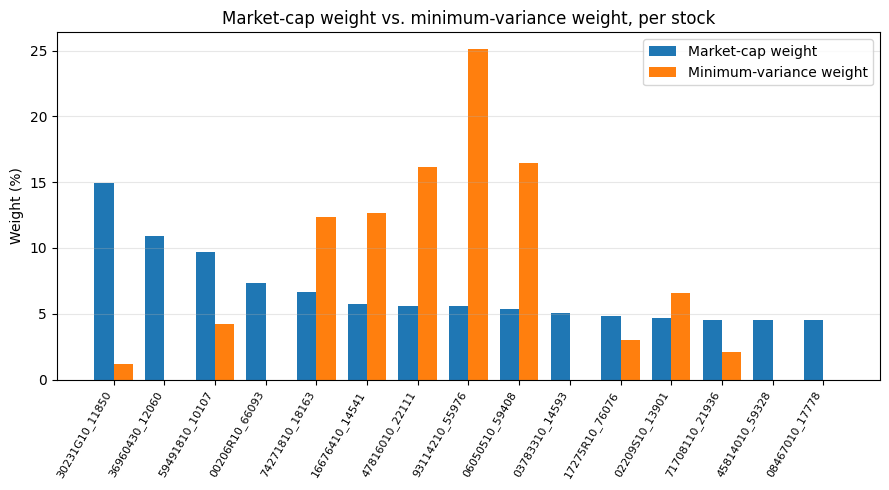

In [12]:
cap_weights = (
    window_end_cap.loc[top_assets]
    .pipe(lambda s: s / s.sum())
    .rename("cap_weight")
)

comparison = weights_table[["mv_weight"]].join(cap_weights).sort_values("cap_weight", ascending=False)
comparison["difference"] = comparison["mv_weight"] - comparison["cap_weight"]

print("Minimum-variance weight vs. market-cap weight, per stock:")
print(comparison)

cap_only_return = float((cap_weights.to_numpy().reshape(-1, 1).T @ mu.loc[cap_weights.index].to_numpy().reshape(-1, 1)).item())
cap_only_vol = float(np.sqrt((cap_weights.to_numpy().reshape(-1, 1).T @ Sigma.loc[cap_weights.index, cap_weights.index].to_numpy() @ cap_weights.to_numpy().reshape(-1, 1)).item()))

print(f"\nMarket-cap-weighted portfolio (same 15 stocks): expected monthly return {cap_only_return:.4f}, "
      f"monthly volatility {cap_only_vol:.4f}")
print(f"Minimum-variance portfolio:                      expected monthly return {min_var_return:.4f}, "
      f"monthly volatility {min_var_vol:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(comparison))
width = 0.38
ax.bar(x_pos - width/2, comparison["cap_weight"] * 100, width, label="Market-cap weight")
ax.bar(x_pos + width/2, comparison["mv_weight"] * 100, width, label="Minimum-variance weight")
ax.set_xticks(x_pos)
ax.set_xticklabels(comparison.index, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Weight (%)")
ax.set_title("Market-cap weight vs. minimum-variance weight, per stock")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("cap_vs_mv_weights.png", dpi=200)
plt.show()

## 11. Did the difference matter? Realized performance through the 2008-2009 crisis

Both weight sets are now **frozen** and propagated forward from January 2008 through December 2009 (24 months), rebalanced monthly back to their respective target weights (so the comparison isolates the weighting choice itself, not price drift). If a stock's return series ends during this period, its weight is dropped and the remaining weights renormalized -- the same convention used elsewhere in this project.

This directly answers the second half of the economic question: did choosing minimum-variance weights over market-cap weights actually matter once the crisis hit?

Minimum-variance portfolio: cumulative return -3.04%, realized monthly volatility 0.0737
Market-cap portfolio:       cumulative return -15.03%, realized monthly volatility 0.0643


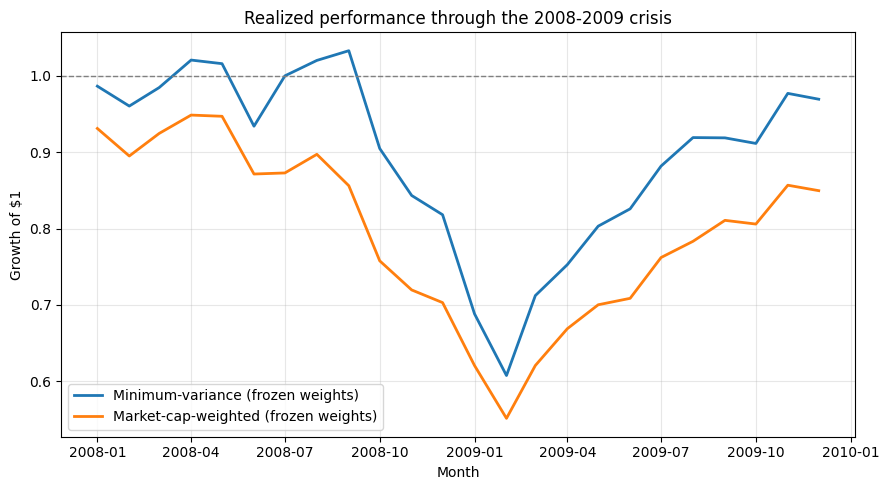

In [13]:
FORWARD_START = pd.Period("2008-01", freq="M")
FORWARD_END = pd.Period("2009-12", freq="M")
forward_months = pd.period_range(FORWARD_START, FORWARD_END, freq="M")

def propagate(weights):
    weights = weights.copy()
    alive = set(weights.index)
    path = []
    for month in forward_months:
        if month not in stock_returns.index:
            break
        this_month = stock_returns.loc[month].dropna()
        available = [a for a in alive if a in this_month.index]
        if not available:
            break
        w = weights.loc[available]
        w = w / w.sum()
        path.append(float((w * this_month.loc[available]).sum()))
        alive = set(available)
    return pd.Series(path, index=forward_months[:len(path)])

mv_path = propagate(weights_table["mv_weight"])
cap_path = propagate(cap_weights)

mv_cum = (1 + mv_path).cumprod()
cap_cum = (1 + cap_path).cumprod()

print(f"Minimum-variance portfolio: cumulative return {mv_cum.iloc[-1] - 1:.2%}, "
      f"realized monthly volatility {mv_path.std():.4f}")
print(f"Market-cap portfolio:       cumulative return {cap_cum.iloc[-1] - 1:.2%}, "
      f"realized monthly volatility {cap_path.std():.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mv_cum.index.to_timestamp(), mv_cum.values, label="Minimum-variance (frozen weights)", linewidth=2)
ax.plot(cap_cum.index.to_timestamp(), cap_cum.values, label="Market-cap-weighted (frozen weights)", linewidth=2)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Month")
ax.set_title("Realized performance through the 2008-2009 crisis")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("crisis_performance.png", dpi=200)
plt.show()

## 12. Means, standard deviations, and the correlation matrix

The full 15-stock universe -- not an excerpt -- so this table doubles as both the required "estimated means, standard deviations, and correlation matrix" table and the input summary for the portfolios above.

In [14]:
summary_table = pd.DataFrame({
    "mean": mu,
    "std": np.sqrt(np.diag(Sigma)),
}).loc[window_filtered.columns]

print("Means and standard deviations (monthly):")
print(summary_table)

correlation_matrix = window_filtered.corr()
print("\nCorrelation matrix:")
correlation_matrix

Means and standard deviations (monthly):
                    mean       std
cusip_crsp_id                     
30231G10_11850  0.019625  0.051288
36960430_12060  0.010124  0.040549
59491810_10107  0.009573  0.057602
00206R10_66093  0.012763  0.056162
74271810_18163  0.011301  0.037021
16676410_14541  0.021407  0.050926
47816010_22111  0.005935  0.033927
93114210_55976  0.001025  0.045405
06050510_59408  0.007070  0.038086
03783310_14593  0.062014  0.105552
17275R10_76076  0.014744  0.073008
02209S10_13901  0.021708  0.073958
71708110_21936 -0.000971  0.053950
45814010_59328  0.013071  0.079372
08467010_17778  0.011882  0.038657

Correlation matrix:


cusip_crsp_id,30231G10_11850,36960430_12060,59491810_10107,00206R10_66093,74271810_18163,16676410_14541,47816010_22111,93114210_55976,06050510_59408,03783310_14593,17275R10_76076,02209S10_13901,71708110_21936,45814010_59328,08467010_17778
cusip_crsp_id,,,,,,,,,,,,,,,
30231G10_11850,1.000000,0.074066,0.147412,0.253953,0.128843,0.812007,0.100072,-0.234672,0.027886,0.371106,-0.020439,0.108584,0.279211,0.030750,0.035658
36960430_12060,0.074066,1.000000,0.322602,0.220940,0.070032,-0.007978,0.246770,0.185877,0.374047,-0.023378,0.364041,-0.083423,-0.091334,0.192217,0.164880
59491810_10107,0.147412,0.322602,1.000000,0.275549,0.079680,0.055945,0.116189,0.012530,0.035057,0.234139,0.207539,0.040862,0.110106,0.141230,0.322913
00206R10_66093,0.253953,0.220940,0.275549,1.000000,0.215363,0.267240,-0.046502,-0.026902,0.222667,0.051198,0.172419,0.239905,0.201099,0.005500,0.269839
74271810_18163,0.128843,0.070032,0.079680,0.215363,1.000000,0.084002,0.432681,-0.116650,0.049590,-0.009210,0.121648,0.084988,0.351548,0.073146,0.133764
16676410_14541,0.812007,-0.007978,0.055945,0.267240,0.084002,1.000000,-0.023108,-0.310479,0.001837,0.409508,0.015900,0.321531,0.241068,0.056541,0.006479
47816010_22111,0.100072,0.246770,0.116189,-0.046502,0.432681,-0.023108,1.000000,0.069999,0.125889,-0.131811,-0.146906,-0.113104,0.140966,-0.034157,0.111752
93114210_55976,-0.234672,0.185877,0.012530,-0.026902,-0.116650,-0.310479,0.069999,1.000000,-0.099006,-0.111999,-0.058601,-0.350496,-0.268839,0.159153,0.367295
06050510_59408,0.027886,0.374047,0.035057,0.222667,0.049590,0.001837,0.125889,-0.099006,1.000000,0.144998,0.244794,0.116007,0.287991,0.153008,0.033685


## 13. Plot the efficient frontier

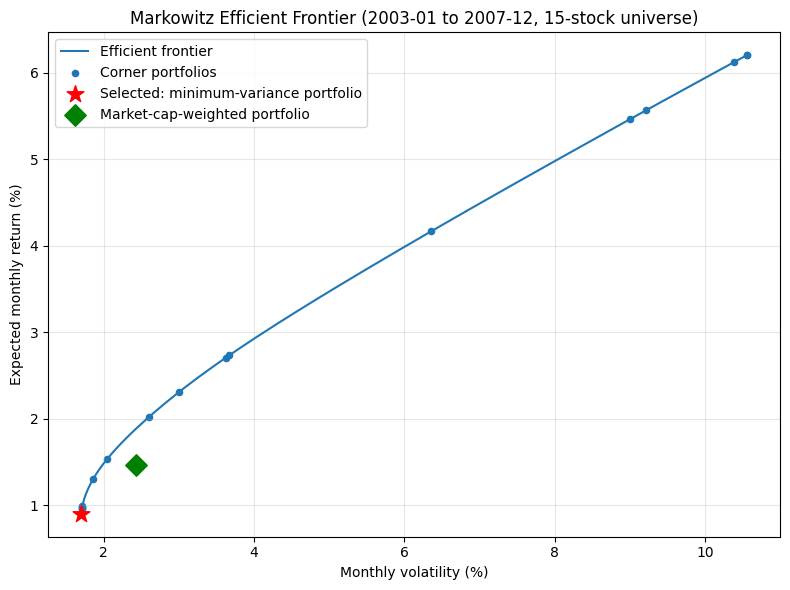

In [15]:
frontier_returns = []
frontier_vols = []

points_per_segment = 20

for i in range(len(corner_weights) - 1):
    w0 = corner_weights[i]
    w1 = corner_weights[i + 1]

    for alpha in np.linspace(0, 1, points_per_segment, endpoint=False):
        w = (1 - alpha) * w0 + alpha * w1
        ret = float((w.T @ mu_vec).item())
        var = float((w.T @ Sigma_mat @ w).item())
        frontier_returns.append(ret)
        frontier_vols.append(np.sqrt(max(var, 0.0)))

w = corner_weights[-1]
frontier_returns.append(float((w.T @ mu_vec).item()))
frontier_vols.append(np.sqrt(max(float((w.T @ Sigma_mat @ w).item()), 0.0)))

plt.figure(figsize=(8, 6))

plt.plot(
    np.array(frontier_vols) * 100,
    np.array(frontier_returns) * 100,
    label="Efficient frontier"
)

plt.scatter(
    np.array(corner_vols) * 100,
    np.array(corner_returns) * 100,
    s=20,
    label="Corner portfolios"
)

plt.scatter(
    [min_var_vol * 100],
    [min_var_return * 100],
    s=160,
    marker="*",
    color="red",
    zorder=5,
    label="Selected: minimum-variance portfolio"
)

plt.scatter(
    [cap_only_vol * 100],
    [cap_only_return * 100],
    s=120,
    marker="D",
    color="green",
    zorder=5,
    label="Market-cap-weighted portfolio"
)

plt.xlabel("Monthly volatility (%)")
plt.ylabel("Expected monthly return (%)")
plt.title("Markowitz Efficient Frontier (2003-01 to 2007-12, 15-stock universe)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("frontier_plot.png", dpi=220)
plt.show()

---

### Reference

Stein, M., Branke, J., & Schmeck, H. (2008). **Efficient implementation of an active set algorithm for large-scale portfolio selection.** *Computers & Operations Research, 35*, 3945-3961.

The implementation above primarily follows the paper's parametric active-set formulation in **Section 2** and the computational improvements based on active-bound substitution and the reduced kernel system in **Sections 4.2-4.3**.